In [ ]:
# Exercise: ex13_covid_data_plots

#13. Com o auxílio dos packages Matplotlib e Seaborn, continue a analisar os datasets do exercício
#anterior, mas agora numa perspetiva mais visual, criando os gráficos solicitados nas alíneas
#que se seguem.
#a) Comece por transferir os DataFrames do exercício anterior para um novo notebook.
#b) Visualize graficamente o grau de correlação existente entre as variáveis numéricas do
#relatório diário da COVID-19 que importou do exercício anterior.
#c) Crie um gráfico de dispersão que relacione os casos confirmados com o número de
#fatalidades, usando quer o package Matplotlib quer o Seaborn. Diga, depois, se a partir
#do gráfico, será possível tirar alguma conclusão quanto à variabilidade da taxa de
#letalidade entre países?
#d) Sobreponha num gráfico de barras os casos ativos, recuperados e fatalidades dos 10
#países com mais casos confirmados, e tire as suas conclusões.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
url = "https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_daily_reports/11-08-2020.csv"
df_country = pd.read_csv(url).groupby('Country_Region')[['Confirmed', 'Recovered', 'Active', 'Deaths']].sum()

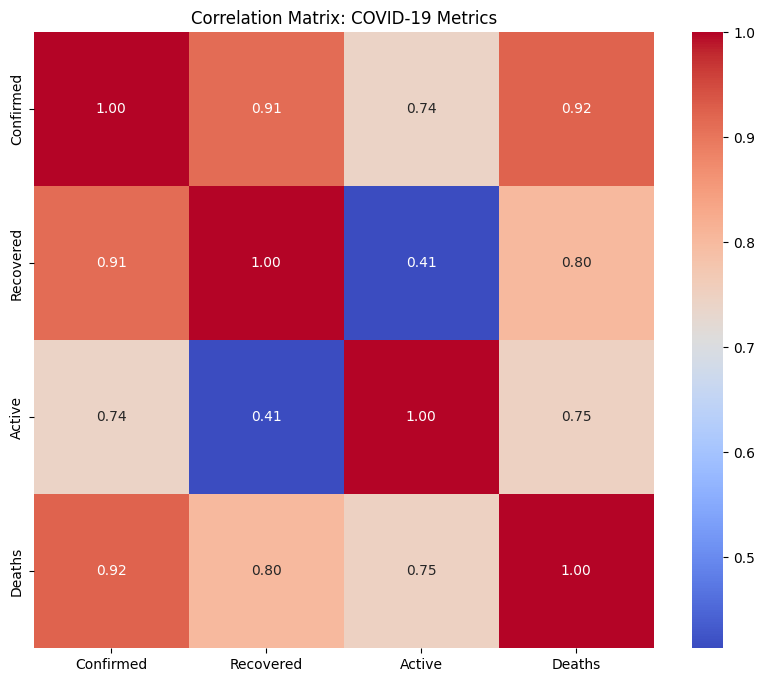

In [6]:
# b) Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df_country.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix: COVID-19 Metrics")
plt.show()

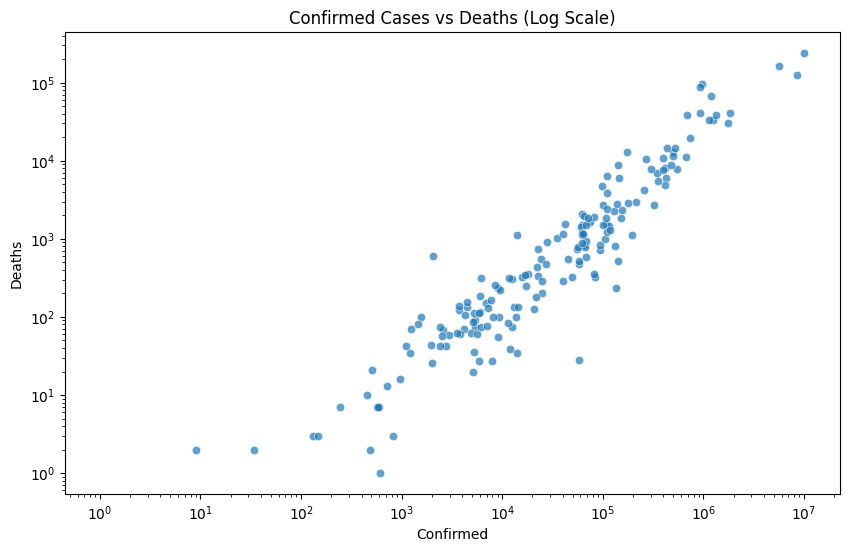

In [7]:
# c) Scatter Plot: Confirmed vs Deaths
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_country, x='Confirmed', y='Deaths', alpha=0.7)
plt.xscale('log'); plt.yscale('log')
plt.title("Confirmed Cases vs Deaths (Log Scale)")
plt.show()

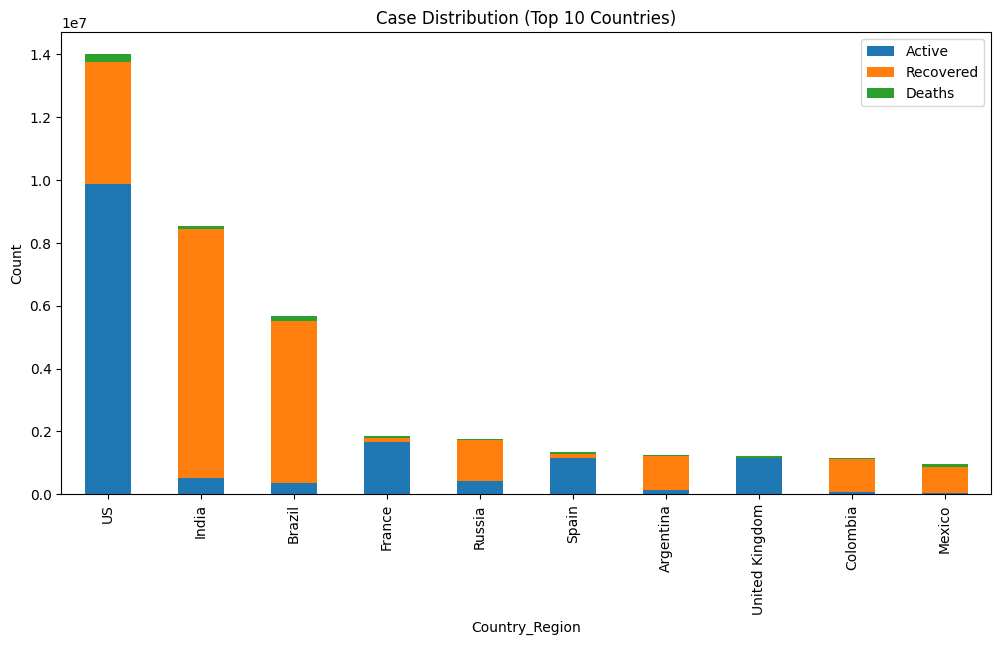

In [8]:
# d) Stacked Bar Plot (Top 10)
top10 = df_country.sort_values('Confirmed', ascending=False).head(10)
top10[['Active', 'Recovered', 'Deaths']].plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title("Case Distribution (Top 10 Countries)")
plt.ylabel("Count")
plt.show()